<a href="https://colab.research.google.com/github/MehulShukla-git/Movie_Recommendation_System/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ANN MODEL**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/movies_metadata.csv')

print(df.head())

   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   
2  False  {'id': 119050, 'name': 'Grumpy Old Men Collect...         0   
3  False                                                NaN  16000000   
4  False  {'id': 96871, 'name': 'Father of the Bride Col...         0   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2  [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...   
3  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
4                     [{'id': 35, 'name': 'Comedy'}]   

                               homepage     id    imdb_id original_language  \
0  http://toystory.disney.com/toy-story    862  tt0114709                en   
1                                   NaN   8844  tt0113497         

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

df = df[['title', 'overview', 'genres','tagline','vote_average','popularity']]

df = df.dropna(subset=['title'])

df['overview'] = df['overview'].fillna('')
df['tagline'] = df['tagline'].fillna('')

In [ ]:
import ast

def extract_genres(x):
    try:
        return " ".join([i['name'] for i in ast.literal_eval(x)])
    except:
        return ""

df['genres'] = df['genres'].apply(extract_genres)

In [ ]:
df['tags'] = df['overview'] + " " + df['genres'] + " " + df['tagline']

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

df['tags'] = df['tags'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
df = df.reset_index(drop=True)

# lowercase mapping (VERY IMPORTANT)
df['title'] = df['title'].str.lower()

indices = pd.Series(df.index, index=df['title']).drop_duplicates()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['tags'])

In [ ]:
from scipy.sparse import hstack

# Convert numeric
df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce').fillna(0)
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce').fillna(0)

X_num = df[['vote_average','popularity']].values

# Combine
X = hstack((tfidf_matrix, X_num))

# 🔥 FIX (IMPORTANT)
X = X.tocsr()

In [ ]:
df['target'] = df['vote_average'].apply(lambda x: 1 if x >= 6 else 0)

y = df['target']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**MODEL**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Convert sparse → dense
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

ann = Sequential()
ann.add(Dense(128, activation='relu', input_dim=X_train_dense.shape[1]))
ann.add(Dense(64, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann.fit(X_train_dense, y_train, epochs=5, batch_size=32)

Epoch 1/5
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 39s 30ms/step - accuracy: 0.8730 - loss: 0.2729
Epoch 2/5
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.9491 - loss: 0.1241
Epoch 3/5
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - accuracy: 0.9729 - loss: 0.0717
Epoch 4/5
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - accuracy: 0.9832 - loss: 0.0466
Epoch 5/5
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - accuracy: 0.9936 - loss: 0.0207


285/285 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
=== ANN ===
Accuracy: 0.9161716171617161
Precision: 0.9301392992823977
F1 Score: 0.9204260651629073
ROC-AUC Score: 0.9786147374364985


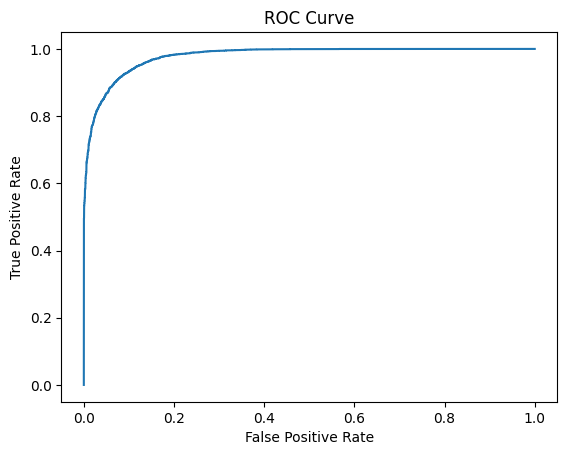

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_curve, roc_auc_score

# Predictions
y_pred_prob = ann.predict(X_test_dense)
y_pred = (y_pred_prob > 0.5).astype("int32")

# Metrics
print("=== ANN ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# ROC AUC
auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC Score:", auc)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_ann(movie_name, top_n=10):
    movie_name = movie_name.lower()

    if movie_name not in indices:
        return "❌ Movie not found"

    idx = indices[movie_name]

    # ANN Prediction
    pred = ann.predict(X[idx].toarray())[0][0]

    # Similarity (MAIN PART 🔥)
    sim_scores = cosine_similarity(X[idx], X).flatten()

    # Get top similar movies
    sim_indices = sim_scores.argsort()[-top_n-1:-1][::-1]

    recommended_movies = df['title'].iloc[sim_indices].values

    print(f"\n🎬 Input Movie: {movie_name}")
    print(f"🤖 ANN Score: {pred:.2f}")

    if pred > 0.5:
        print("✅ Recommended Movies:\n")
    else:
        print("⚠️ Not highly rated, but similar movies:\n")

    for i, movie in enumerate(recommended_movies, 1):
        print(f"{i}. {movie}")

In [ ]:
movie = input("Enter movie name: ").lower()
print(recommend_ann(movie))

Enter movie name: Toy Story
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

🎬 Input Movie: toy story
🤖 ANN Score: 1.00
✅ Recommended Movies:

1. a dog's will
2. black mirror: white christmas
3. gladiator
4. 2001: a space odyssey
5. alien
6. terminator 2: judgment day
7. train to busan
8. aliens
9. inside out
10. mulan
None
